<a href="https://colab.research.google.com/github/Islam-Astro/Photometric-Analysis-for-M57/blob/main/Photometry_Technique_Toutrial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Photometry Technique Tutorial

Welcome to the Photometry Technique tutorial. In this notebook, we will explore the methods used to measure the apparent magnitude (m) of celestial objects in astronomical images. This tutorial focuses on extracting and analyzing photometric data from reduced files, ensuring accurate and reliable measurements.

## Note on Usage

This notebook is designed to be used primarily online via Google Colab. To edit and run the notebook, please follow these steps:

- **Make a Copy**: Since the shared notebook is set to view-only, you will need to make a copy to your own Google Drive. To do this, open the notebook in Google Colab, go to `File` > `Save a copy in Drive`. This will create an editable version in your Google Drive that you can run and modify as needed.

For those who prefer to work offline, you can download the notebook and run it on your local machine. This requires a Python environment with the necessary packages installed. Ensure you have access to the reduced data files locally and adjust the file paths accordingly.

Choose the option that best suits your needs and follow the instructions provided in each section to complete the tutorial.

## What You'll Learn

In this tutorial, we will cover the following key steps:

- **Image Preparation**: Loading and visualizing reduced astronomical images.
- **Star Detection**: Using algorithms to identify and locate stars within the images.
- **Aperture Photometry**: Measuring the brightness of stars using aperture photometry techniques, including background subtraction and flux calculation.
- **Astroquery Usage**: Utilizing the Astroquery library to access and retrieve data from astronomical catalogs such as Gaia, enhancing your photometric analysis with additional data.
- **Magnitude Calibration**: Calibrating instrumental magnitudes to standard magnitudes using zero-point calculations.

## About the Author

This tutorial was created by Islam Fathallah. Feel free to connect with me or explore more of my work through the following platforms:

- [LinkedIn](https://www.linkedin.com/in/islam-fathallah/)
- [GitHub](https://github.com/Islam-Astro)
- Email: eslamalaa886@gmail.com

## Acknowledgments

This tutorial was developed based on the foundational work of Professor Ali Takey and the insights gained from the repository by Isabell Hudnall (https://github.com/laingmic005/aperture-photometry.git). Special thanks to Isabell for her contributions, which inspired the core methodology used here. Additional steps, such as catalog querying, error determination, and zero-point determination, have been integrated to enhance the original approach. We also extend our gratitude to the developers of the libraries used in this tutorial for their invaluable contributions to the scientific community.

## Important Note

The photometry techniques demonstrated in this notebook should be applied to reduced files. Using reduced files ensures that systematic errors have been corrected, allowing for precise and accurate photometric measurements.

To begin with data reduction, please refer to the [Basic Data Reduction Tutorial](https://colab.research.google.com/drive/1RX3rnoCdAvg42Tjn5f5SPjfiQyhNRNhP?authuser=1#scrollTo=efMdIsc5yG-s). This foundational tutorial will guide you through the essential steps of preparing your data for photometric analysis.

# Getting Started


---


## Installing Required Packages

Before we begin our photometry analysis, we need to ensure that all the necessary Python packages are installed. These packages provide essential tools for data handling, image processing, and astronomical analysis. Run the following commands to install the required packages:

In [ ]:
!pip install photutils
!pip install acstools
!pip install stdpipe
!pip install astroquery
!pip install acstools

## Importing Essential Libraries

In this section, we import the essential libraries and modules that will be used throughout the notebook. Each library serves a specific purpose in the photometry analysis process:

- **math**: Provides mathematical functions and constants.
- **numpy**: A fundamental package for numerical computations in Python, used for handling arrays and mathematical operations. [NumPy Documentation](https://numpy.org/doc/)
- **matplotlib.pyplot**: A plotting library for creating static, interactive, and animated visualizations in Python. [Matplotlib Documentation](https://matplotlib.org/stable/contents.html)
- **astropy.io.fits**: A module for reading and writing FITS (Flexible Image Transport System) files, the standard data format in astronomy. [Astropy FITS Documentation](https://docs.astropy.org/en/stable/io/fits/)
- **astropy.stats**: Provides statistical functions, including `sigma_clipped_stats` for robust statistics. [Astropy Stats Documentation](https://docs.astropy.org/en/stable/stats/)
- **astropy.wcs**: A module for handling World Coordinate System (WCS) transformations, crucial for mapping pixel coordinates to celestial coordinates. [Astropy WCS Documentation](https://docs.astropy.org/en/stable/wcs/)
- **astropy.table**: Tools for creating and manipulating tables of data. [Astropy Table Documentation](https://docs.astropy.org/en/stable/table/)
- **astropy.coordinates**: Provides classes for representing and transforming celestial coordinates. [Astropy Coordinates Documentation](https://docs.astropy.org/en/stable/coordinates/)
- **astropy.units**: Used for handling units and conversions in astronomical data. [Astropy Units Documentation](https://docs.astropy.org/en/stable/units/)
- **astropy.modeling**: Tools for modeling and fitting data. [Astropy Modeling Documentation](https://docs.astropy.org/en/stable/modeling/)
- **astropy.visualization**: Provides tools for visualizing astronomical data, including scaling and normalization. [Astropy Visualization Documentation](https://docs.astropy.org/en/stable/visualization/)
- **photutils**: A package for detecting and performing photometry on astronomical sources. [Photutils Documentation](https://photutils.readthedocs.io/en/stable/)
- **acstools**: Tools for working with data from the Advanced Camera for Surveys (ACS) from Space Telescope Science Institute (STSci). [ACSTools Documentation](https://acstools.readthedocs.io/en/stable/)
- **stdpipe**: A standard pipeline for astronomical data processing tasks. [Stdpipe Documentation](https://stdpipe.readthedocs.io/en/latest/)
- **astroquery**: A library for querying astronomical databases and retrieving data. [Astroquery Documentation](https://astroquery.readthedocs.io/en/latest/)
- **matplotlib.colors**: Provides color normalization tools for visualizations. [Matplotlib Colors Documentation](https://matplotlib.org/stable/tutorials/colors/colors.html)


In [ ]:
# Import necessary libraries
import math
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.stats import sigma_clipped_stats
from astropy.wcs import WCS
from astropy.table import Table, Column
from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.modeling import models, fitting
from astropy.visualization import ZScaleInterval
from photutils.detection import DAOStarFinder, find_peaks
from photutils.aperture import CircularAperture, CircularAnnulus, CircularAnnulus, ApertureStats, aperture_photometry
from acstools import acszpt
from stdpipe import plots
from astroquery.vizier import Vizier
from astroquery.gaia import Gaia
from acstools import acszpt
from matplotlib.colors import LogNorm

## Accessing Data from Google Drive

To work with the data files stored in your Google Drive, we need to mount the drive in Google Colab. This allows us to access and manipulate files directly from your Drive within the notebook.



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## Configuring Image Visualization Settings

To standardize how images are displayed throughout the tutorial, we adjust the default settings of Matplotlib. This ensures consistency and clarity in visualizing the processed data.

- **Image Origin**: We set the origin of images to be displayed in the bottom-left corner (`origin='lower'`), aligning with astronomical conventions.
- **Colormap**: The colormap is set to grayscale (`cmap='gray'`), which is widely used for astronomical image visualization to highlight intensity variations without color biases.

These settings help maintain a consistent visual representation of the data, making it easier to interpret the results.

In [ ]:
plt.rc('image', origin='lower', cmap='gray')

## Opening and Displaying a FITS File

In this section, we open a FITS file containing astronomical image data and display the full image. FITS (Flexible Image Transport System) is a standard format used in astronomy for storing image data and metadata.

- **Open FITS File**: We use `astropy.io.fits` to open the FITS file located in your Google Drive. The file path should be adjusted to point to the specific file you wish to analyze.

- **Extract Image Data**: The image data is extracted from the first extension of the FITS file, which typically contains the primary image.

- **Display the Image**: We use Matplotlib to display the full image. The `plots.imshow` function is used to visualize the data, with intensity limits set to the 0.5th and 99.7th percentiles to enhance visibility.

### Important Notes:
- **File Path**: Ensure that the file path is correct and points to the desired FITS file in your Google Drive. Adjust the path as needed for your specific setup.
- **Data Integrity**: Verify that the FITS file is not corrupted and contains valid image data before proceeding with further analysis.

By opening and displaying the FITS file, we gain an initial visual understanding of the data, setting the stage for further photometric analysis.

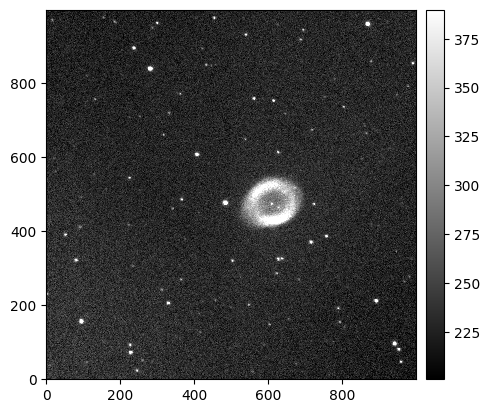

In [ ]:
# Open FITS file
fits_file = fits.open('/content/drive/MyDrive/V_20240419_0054.fits')
image_data = fits_file[0].data

# Display the full image
plt.figure()
plots.imshow(image_data, [0.5, 99.7], interpolation='nearest')
plt.show()

## Accessing the FITS File Header

We extract and display the header of the FITS file to review the metadata associated with the image. This metadata includes crucial information about the observation, such as the telescope used, observation date, and exposure time.

### Quick Tips:
- **Review Metadata**: Check the header for key details that inform your analysis.
- **Common Keys**: Look for keys like `DATE-OBS`, `EXPTIME`, and `FILTER`.

Understanding the header helps provide context for the image data, essential for accurate analysis.

In [ ]:
image_header = fits_file[0].header
image_header

# Stars Detection


---


## Calculating Background Statistics and Detecting Stars

In this step, we calculate background statistics and detect stars within our frame

- **Background Statistics**: We use `sigma_clipped_stats` to compute the mean, median, and standard deviation of the background, which helps in distinguishing stars from noise.

- **Star Detection**: Using `DAOStarFinder`, we identify stars in the image section. The function detects stars based on their full width at half maximum (FWHM) and a threshold set relative to the background noise.

These steps are crucial for isolating stars from the background, enabling accurate photometric measurements.

In [ ]:
# Calculate background statistics
mean, median, std = sigma_clipped_stats(image_data, sigma=3.0)

# Detect stars
daofind = DAOStarFinder(fwhm=3.0, threshold=5.0 * std)
sources = daofind(image_data - median)
sources

## Displaying Detected Stars

We visualize the stars detected in our frame to confirm their positions.

- **Star Positions**: The positions of detected stars are extracted and used to create circular apertures.

- **Visualization**: The image section is displayed with overlaid apertures marking the detected stars. This helps verify the accuracy of the star detection process.

Visualizing detected stars ensures that our detection algorithm is correctly identifying stellar objects in the image.

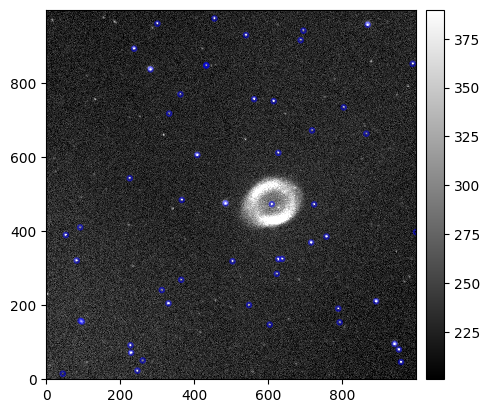

In [ ]:
# Display detected stars
positions = np.transpose((sources['xcentroid'], sources['ycentroid']))
apertures = CircularAperture(positions, r=6.0)
plt.figure()
plots.imshow(image_data, [0.5, 99.7], interpolation='nearest')
apertures.plot(color='blue', lw=1.5, alpha=0.5)
plt.savefig('Detected Stars' , format='png')
plt.show()

## Masking Bright Regions and Re-detecting Stars

To improve star detection accuracy, we create a mask to exclude bright regions and any conflicting stars that may interfere with the process.

- **Create Mask**: A boolean mask is defined to cover bright areas in the image section, preventing them from affecting star detection.

- **Re-detect Stars**: With the mask applied, we re-run the star detection algorithm to identify stars more accurately.

- **Visualization**: The updated star positions are displayed with overlaid apertures, confirming the effectiveness of the masking process.

By excluding bright regions, we enhance the reliability of our star detection, focusing on genuine stellar objects.

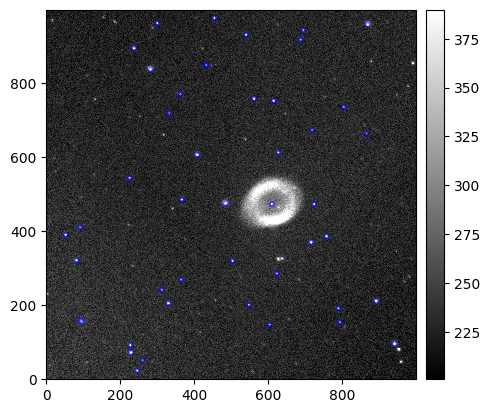

In [ ]:
# Create a mask to exclude bright regions

mask = np.zeros(image_data.shape, dtype=bool)
mask[0:30, 0:50] = True  # mask=[y1:y2, x1:x2]
mask[300:400, 600:700] = True
mask[0:1000, 950:1000] = True

# Re-detect stars with the mask applied
sources = daofind(image_data - median, mask=mask)
positions = np.transpose((sources['xcentroid'], sources['ycentroid']))
apertures = CircularAperture(positions, r=6.0)
# Display the updated detection
plt.figure()
plots.imshow(image_data, [0.5, 99.7], interpolation='nearest')
apertures.plot(color='blue', lw=1.5, alpha=0.5)
plt.savefig('Stars Detected with Mask', format='png')
plt.show()

## Measuring Background with Annuli

We use annuli to measure the background around detected stars, which is crucial for accurate photometric analysis.

- **Define Annuli**: Circular annuli are created around each detected star to measure the local background. The inner and outer radii are set to 12 and 118 pixels, respectively.

- **Background Measurement**: Using `ApertureStats`, we calculate the mean background level within the annuli.

- **Visualization**: The annuli are plotted over the image section, alongside the detected stars, to visually confirm the background measurement setup.

By accurately measuring the background, we can subtract it from the star's total flux, ensuring precise photometric results.

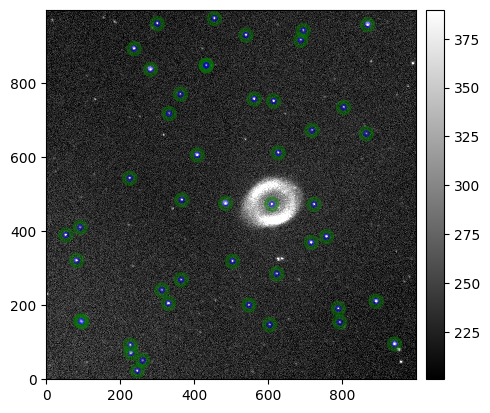

In [ ]:
# Define annuli for background measurement
annulus_aperture = CircularAnnulus(positions, r_in=12, r_out=18)
aperstats = ApertureStats(image_data, annulus_aperture)

# Plot the annuli
plt.figure()
plots.imshow(image_data, [0.5, 99.7], interpolation='nearest')
apertures.plot(color='blue', lw=1.5, alpha=0.5)
annulus_aperture.plot(color='green', lw=1.5, alpha=0.5)
plt.savefig('Annual Background', format='png')
plt.show()

# Calculate background
bkg_mean = aperstats.mean
aperture_area = apertures.area_overlap(image_data)
total_bkg = bkg_mean * aperture_area


## Performing Aperture Photometry

We perform aperture photometry to measure the brightness of detected stars, accounting for background contributions.

- **Aperture Photometry**: Using the defined apertures, we calculate the total flux for each star in the frame.

- **Background Subtraction**: The calculated background is added to the photometry table and subtracted from the total flux to obtain the net star flux.

- **Display Results**: The photometry table is displayed, showing the measured flux and background for each star.

This process provides accurate measurements of stellar brightness, essential for further photometric analysis.

In [ ]:
# Perform aperture photometry
star_data = aperture_photometry(image_data, apertures)

# Add background data to the photometry table
star_data['total_bkg'] = total_bkg

# Display the photometry table
for col in star_data.colnames:
    star_data[col].info.format = '%.8g'
star_data.pprint()


 id  xcenter   ycenter  aperture_sum total_bkg
--- --------- --------- ------------ ---------
  1 246.64074 22.774614     33342.22  27027.63
  2  260.9162 50.410631    29592.131 26864.223
  3 229.53939 71.364935     48495.31 27396.897
  4 227.94976 91.319348    35814.198  28054.77
  5 942.29343 95.224003    66378.541 26521.575
  6 604.53685 147.20573    29279.036 26091.518
  7 793.84901 153.58274    29939.712 25695.509
  8 96.526549 155.43308    61300.649 27461.714
  9 92.640549 157.69703    54213.327 27484.617
 10 789.96765 190.66655    31353.967 25736.803
...       ...       ...          ...       ...
 37 282.12697 837.88536    78051.675 25972.368
 38 433.05013   848.783    30001.355 26037.495
 39  432.6142 848.46795    29965.116 26030.422
 40 237.70936 893.91177    42019.684 25601.892
 41 688.27076 916.92049    30207.984 26065.564
 42 540.42378 930.49982    32038.442 26024.761
 43 695.58726 942.60941    30386.843  25946.98
 44 869.51778 958.80322    82362.055  26357.65
 45 300.63853

## Computing Flux and Uncertainty

We calculate the flux and its uncertainty for each detected star, incorporating various noise sources to ensure accurate photometric measurements.

- **Aperture Photometry**: We perform aperture photometry to obtain the total flux for each star, subtracting the calculated background.

- **Noise Calculation**:
  - **Photon Noise**: Calculated from the flux, considering the gain (electrons/ADU).
  - **Background Noise**: Derived from the standard deviation of the background.
  - **Readout Noise**: Based on the readout noise (RON) and aperture area.

- **Flux Uncertainty**: The total uncertainty is computed by combining photon, background, and readout noise.

- **Update Photometry Table**: The flux and its uncertainty are added to the photometry table for each star.

This step ensures that our photometric measurements account for all significant sources of noise, providing reliable data for further analysis.

In [ ]:
GAIN = 2.14  # These values are based on your detector (CCD) information
RON = 3.92

# Perform aperture photometry
star_data = aperture_photometry(image_data, apertures)

# Calculate total background per star
bkg_mean = aperstats.mean
aperture_area = apertures.area_overlap(image_data)
total_bkg = bkg_mean * aperture_area

# Compute flux and flux uncertainty
flux = star_data['aperture_sum'] - total_bkg
photon_noise = np.sqrt(flux * GAIN)  # Photon noise (convert ADU to electrons)
background_noise = np.sqrt(aperture_area * (std ** 2))  # Background noise
readout_noise = RON * np.sqrt(aperture_area)  # Readout noise
flux_uncertainty = np.sqrt(photon_noise ** 2 + background_noise ** 2 + readout_noise ** 2)

# Add flux and flux uncertainty to the table
star_data['total_bkg'] = total_bkg
star_data['flux'] = flux
star_data['flux_uncertainty'] = flux_uncertainty

## Calculating Instrumental Magnitudes and Uncertainties

We convert the measured fluxes into instrumental magnitudes and calculate their uncertainties, which are essential for photometric analysis.

- **Instrumental Magnitudes**: Using the formula $$m = -2.5 \times \log_{10}(\text{flux} / \text{exposure time})$$, we compute the magnitude for each star.

- **Magnitude Uncertainty**: Calculated based on the flux uncertainty, providing an estimate of the error in the magnitude measurement.

- **Update Photometry Table**: The computed magnitudes and their uncertainties are added to the photometry table for each star.

This step translates flux measurements into a standard photometric scale, allowing for comparison and further analysis.

In [ ]:
# Calculate instrumental magnitudes and their uncertainties
extime = 60.0  # Exposure time from header
m_inst = []
m_inst_uncertainty = []

for line in star_data:
    flux_val = line['flux']
    flux_err = line['flux_uncertainty']

    # Compute magnitude
    mag = -2.5 * math.log10(flux_val / extime)
    m_inst.append(mag)

    # Compute magnitude uncertainty
    mag_err = (2.5 / np.log(10)) * (flux_err / flux_val)
    m_inst_uncertainty.append(mag_err)

# Add magnitudes and their uncertainties to the table
star_data['m_inst'] = m_inst
star_data['m_inst_uncertainty'] = m_inst_uncertainty

# Display the photometry table with errors
for col in star_data.colnames:
    star_data[col].info.format = '%.8g'
star_data.pprint(max_lines=-1, max_width=-1)

 id  xcenter   ycenter  aperture_sum total_bkg    flux   flux_uncertainty   m_inst   m_inst_uncertainty
--- --------- --------- ------------ --------- --------- ---------------- ---------- ------------------
  1 246.64074 22.774614     33342.22  27027.63 6314.5903        176.29682 -5.0554848         0.03031263
  2  260.9162 50.410631    29592.131 26864.223 2727.9075        152.98715  -4.144196        0.060890512
  3 229.53939 71.364935     48495.31 27396.897 21098.413        250.43552 -6.3652464        0.012887553
  4 227.94976 91.319348    35814.198  28054.77 7759.4284        184.85812 -5.2791962        0.025866229
  5 942.29343 95.224003    66378.541 26521.575 39856.966         320.7199 -7.0558825       0.0087366712
  6 604.53685 147.20573    29279.036 26091.518 3187.5187        156.16861 -4.3132537        0.053194329
  7 793.84901 153.58274    29939.712 25695.509 4244.2034         163.2481 -4.6241123        0.041761516
  8 96.526549 155.43308    61300.649 27461.714 33838.935        

## Initializing World Coordinate System (WCS)

We initialize the World Coordinate System (WCS) using the FITS file header to map pixel coordinates to celestial coordinates.

- **WCS Initialization**: The WCS object is created from the FITS header, which contains the necessary information for coordinate transformations.

- **Display WCS**: The WCS object is displayed to confirm its successful initialization.

This step is crucial for converting pixel positions to celestial coordinates, enabling accurate astrometric analysis.

In [ ]:
wcs = WCS(fits_file[0].header)

wcs

## Converting Pixel Coordinates to Celestial Coordinates

We convert the pixel coordinates of detected stars to celestial coordinates (RA and Dec) using the WCS, and update the photometry table.

- **Extract Pixel Coordinates**: The `xcenter` and `ycenter` positions of stars are extracted from the photometry table.

- **Coordinate Conversion**: Using the WCS, pixel coordinates are transformed into Right Ascension (RA) and Declination (Dec).

- **Update Photometry Table**: The RA and Dec values are added as new columns to the table, providing celestial positions for each star.

This step integrates astrometric information into our photometric analysis, enabling precise mapping of stars in the sky.

In [ ]:
# Extract pixel coordinates from the table
xcenter = star_data['xcenter']
ycenter = star_data['ycenter']

# Convert pixel coordinates to RA and Dec
world_coords = wcs.pixel_to_world(xcenter, ycenter)

# Extract RA and Dec from the SkyCoord object
ra_deg = world_coords.ra.deg  # RA in degrees
dec_deg = world_coords.dec.deg  # Dec in degrees

# Add RA and Dec as new columns to the table
star_data['RA_deg'] = Column(ra_deg, name='RA_deg', format='%.8g')
star_data['Dec_deg'] = Column(dec_deg, name='Dec_deg', format='%.8g')

# Display the updated photometry table
star_data.write('ap_phot_V.csv', format='csv', overwrite=True) #This line is used to save your final table
star_data

id,xcenter,ycenter,aperture_sum,total_bkg,flux,flux_uncertainty,m_inst,m_inst_uncertainty,RA_deg,Dec_deg
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
1,246.64074,22.774614,33342.22,27027.63,6314.5903,176.29682,-5.0554848,0.03031263,283.45034,33.090546
2,260.9162,50.410631,29592.131,26864.223,2727.9075,152.98715,-4.144196,0.060890512,283.44827,33.086834
3,229.53939,71.364935,48495.31,27396.897,21098.413,250.43552,-6.3652464,0.012887553,283.45335,33.084266
4,227.94976,91.319348,35814.198,28054.77,7759.4284,184.85812,-5.2791962,0.025866229,283.45373,33.081655
5,942.29343,95.224003,66378.541,26521.575,39856.966,320.7199,-7.0558825,0.0087366712,283.34175,33.076798
6,604.53685,147.20573,29279.036,26091.518,3187.5187,156.16861,-4.3132537,0.053194329,283.39493,33.072076
7,793.84901,153.58274,29939.712,25695.509,4244.2034,163.2481,-4.6241123,0.041761516,283.36533,33.07008
8,96.526549,155.43308,61300.649,27461.714,33838.935,299.97111,-6.8781636,0.009624697,283.47488,33.073989
9,92.640549,157.69703,54213.327,27484.617,26728.71,273.43516,-6.6220669,0.0111071,283.47551,33.073714


## Determining the Photometric Zero Point

In photometry, the zero point is crucial for converting instrumental magnitudes to standard magnitudes. There are two common methods for determining the zero point:

### Method 1: Using Catalog Data for Known Instruments

For well-characterized instruments and filters, such as those from the Space Telescope Science Institute (STSci), you can directly get the zero point from a catalog:
  


In [ ]:
# find date, instrument, and filter from the header

q = acszpt.Query(date = date, detector = instrument)
zpt_table = q.fetch()
q_filter = acszpt.Query(date = date, detector = instrument, filt = filter)
filter_zpt = q_filter.fetch()

# print data
print(filter_zpt)

### Next Steps: Calculating Magnitudes

Once you have the zero point, you can calculate the magnitudes of your detected stars using the following equation:

$$
\text{m} = \text{Z_point} - 2.5 \times \log_{10}\left(\frac{\text{F}}{\text{t_exp}}\right)
$$

This equation allows you to convert the measured fluxes into standard magnitudes, accounting for the exposure time and background.

---


### Method 2: Matching with Known Catalogs (The method we used here):

If you are working with instruments or filters that do not have pre-calibrated zero points, or if you prefer a more empirical approach, you can use this method. This involves matching your detected stars with known catalogs to determine the zero point based on standard stars. This method ensures that your calibration is tailored to the specific conditions of your observation.



## Querying GAIA DR3 for Photometric Calibration

To ensure robust photometric calibration, we used the Gaia DR3 catalog, which provides high-precision astrometric and photometric data.

- **Gaia Catalog DR3**: Offers high-precision astrometric data and photometric information.

Using Gaia DR3 ensures the reliability of our photometric calibration, allowing us to compute final calibrated magnitudes with confidence.


In [ ]:
# Define the center of your frame and its search radius
center_ra = wcs.wcs.crval[0]  # RA (degrees)
center_dec = wcs.wcs.crval[1]  # Dec (degrees)
radius = 7 * u.arcmin  # based on your frame size

# Construct the query
query = f"""
SELECT
    source_id, ra, dec, phot_g_mean_mag, phot_bp_mean_mag, phot_rp_mean_mag,
    bp_rp, phot_variable_flag, parallax, pmra, pmdec
FROM gaiadr3.gaia_source
WHERE 1 = CONTAINS(
    POINT('ICRS', ra, dec),
    CIRCLE('ICRS', {center_ra}, {center_dec}, {radius.to(u.deg).value})
)
"""
# Execute the query
job = Gaia.launch_job(query)
results = job.get_results()

# Display the results
print(results)

# Save the results to a CSV file
results.write("gaia_dr3_query_results.csv", format="csv", overwrite=True)


     source_id              ra         ...         pmra                pmdec        
                           deg         ...       mas / yr             mas / yr      
------------------- ------------------ ... ------------------- ---------------------
2090482014576932480  283.4129213603692 ...                  --                    --
2090482014579705344  283.4084180993967 ...                  --                    --
2090483487750496512  283.4817925739744 ... -2.6137159360111553    -4.110452617659155
2090480502752982400 283.39149760399573 ...  -0.663784453852892    -5.324936674804977
2090480502752982528  283.3895385742284 ... -5.3369001454543366    -5.280577036237993
2090480502752986496 283.39710807872825 ... -3.0721362388795503    -4.661595347871202
2090480532812625280 283.40483413516495 ...  -2.541334023440935 -0.009956237131966871
2090480532812643328 283.39783364262837 ...  1.5534764020212224     7.788239498567069
2090480532812644224 283.40249347485155 ... -1.1730537387999465   

## Matching Detected Stars with Gaia DR3

After querying the Gaia DR3 catalog, the next step is to match the stars detected in our frame with the Gaia DR3 data. This process allows us to gain additional information about the stars, identify potential standard stars, and assess their suitability for photometric calibration.

### Matching Criteria

- **Coordinate Matching**:  
  Stars are matched in `TOPCAT` software based on their Right Ascension (RA) and Declination (Dec) coordinates.

- **Photometric Filters**:  
  Gaia’s `phot_g_mean_mag`, `phot_bp_mean_mag`, and `phot_rp_mean_mag` are included to compare with the detected stars' magnitudes and assess their spectral characteristics.

- **Variability Check**:  
  The `phot_variable_flag` from Gaia DR3 is used to filter out variable stars that may not be suitable as standard stars.

### Task: Implement Matching in Python

As an exercise, try implementing the matching process in Python using to cross-match detected stars with Gaia DR3 and analyze the extracted information to identify reliable standard stars.


## Reading the Matched Star Table

After performing the matching process, we read the table containing the matched stars. This table is essential for subsequent photometric calibration and analysis.

- **Load Matched Data**: We use `astropy.table.Table` to read the matched star data from a CSV file. This file contains stars that have been successfully matched based on their celestial coordinates.

- **Verify Matches**: Display the matched table to verify that the data has been loaded correctly and that the matches are consistent with the criteria used.

In [ ]:
matched_table = Table.read('/content/drive/MyDrive/M57/Source Code/GAIA_matched_V.csv', format='ascii')

matched_table

id,xcenter,ycenter,aperture_sum,total_bkg,flux,flux_uncertainty,m_inst,m_inst_uncertainty,RA_deg,Dec_deg,SOURCE_ID,ra,dec,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag,bp_rp,phot_variable_flag,parallax,pmra,pmdec,Separation
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str13,float64,float64,float64,float64
1,246.64074,22.774614,33342.22,27027.63,6314.5903,176.29682,-5.0554848,0.030312631,283.45034,33.090546,2.09049276917978e+18,283.450351755128,33.0904635585327,15.4857473373413,15.7055368423462,15.1179685592651,0.587568283081055,NOT_AVAILABLE,0.197533753992558,-3.12121940401407,-3.03459984341683,0.298899515784887
2,260.9162,50.410631,29592.131,26864.223,2727.9075,152.98715,-4.144196,0.060890513,283.44827,33.086834,2.0904927004603e+18,283.448335506201,33.0868090849277,16.1808986663818,16.709451675415,15.4984827041626,1.21096897125244,NOT_AVAILABLE,-0.0127131504972342,-1.16121366504471,-1.67571281452786,0.216988158433815
3,229.53939,71.364935,48495.31,27396.897,21098.413,250.43552,-6.3652464,0.012887553,283.45335,33.084266,2.0904927004603e+18,283.453410689879,33.0842302075018,14.1497964859009,14.4416456222534,13.6945867538452,0.747058868408203,NOT_AVAILABLE,0.821134880929199,-3.65743314901425,-13.0106074038153,0.22386215679945
4,227.94976,91.319348,35814.198,28054.77,7759.4284,184.85812,-5.2791962,0.025866229,283.45373,33.081655,2.0904927004603e+18,283.453803789185,33.0816272543321,15.0909938812256,15.4299221038818,14.5865564346313,0.843365669250488,NOT_AVAILABLE,0.633641631155655,-5.81625917255424,-13.6763108278434,0.243963704537787
5,942.29343,95.224003,66378.541,26521.575,39856.966,320.7199,-7.0558825,0.0087366712,283.34175,33.076798,2.09048740906051e+18,283.341927618375,33.0767033907738,13.5443325042725,13.8313694000244,13.1022071838379,0.729162216186523,NOT_AVAILABLE,0.693259359357388,0.655221260974111,-0.159629757477972,0.634890814984341
6,604.53685,147.20573,29279.036,26091.518,3187.5187,156.16862,-4.3132537,0.05319433,283.39493,33.072076,2.09048702680371e+18,283.394986070753,33.0721803740831,16.2196140289307,16.5563869476318,15.5821313858032,0.974255561828613,NOT_AVAILABLE,0.445567509590845,-3.35476313453506,-10.9319625613926,0.412065125393294
7,793.84901,153.58274,29939.712,25695.509,4244.2034,163.2481,-4.6241123,0.041761517,283.36533,33.07008,2.09048771829817e+18,283.365315839822,33.0700652194993,15.4846658706665,16.3115711212158,14.3228607177734,1.98871040344238,NOT_AVAILABLE,4.20159035369205,-1.65707918767837,20.3907986050521,0.0682360869131555
8,96.526549,155.43308,61300.649,27461.714,33838.935,299.97111,-6.8781636,0.009624697,283.47488,33.073989,2.09048974552281e+18,283.474813808852,33.0739143848371,13.6342849731445,13.9611806869507,13.1463117599487,0.814868927001953,NOT_AVAILABLE,1.41233113296318,4.11450886215253,-7.80915871952552,0.33470125190146
10,789.96765,190.66655,31353.967,25736.803,5617.1641,172.01185,-4.9284146,0.033248005,283.36619,33.065242,2.09048696238392e+18,283.366193781411,33.065318336743,15.5538511276245,15.9946479797363,14.9552478790283,1.03940010070801,NOT_AVAILABLE,0.635340156027491,-1.15746768113517,-11.491466312737,0.275048975269207


## Calculating the Photometric Zero Point

With the matched star data, we can calculate the photometric zero point, which is crucial for converting instrumental magnitudes to standard magnitudes.

- **Zero Point Calculation**: The zero point is determined by comparing the known standard magnitude (`phot_g_mean_mag`) from the catalog with the instrumental magnitude (`m_inst`) for a candidate standard star. This difference provides the zero point needed for calibration.

- **Example Calculation**: Here, we calculate the zero point for a star that can be used based on its information and its counts on our detector. We also select a star that is close to our target to reduce atmospheric effects. This value will be used to adjust the instrumental magnitudes of all detected stars.



In [ ]:
z_point = matched_table[20]['phot_g_mean_mag']-matched_table[20]['m_inst']

print('Zero point=' ,z_point)

Zero point= 20.557191790454098


## Calibrating Instrumental Magnitudes

Using the calculated zero point, we convert the instrumental magnitudes of our detected stars to calibrated magnitudes in the standard system.

- **Apply Zero Point**: The zero point is added to the instrumental magnitudes (`m_inst`) to obtain the calibrated magnitudes (`Vmag_cal`). This adjustment aligns our measurements with the standard photometric system.

- **Update Photometry Table**: The calibrated magnitudes are added to the photometry table, providing a complete dataset for further analysis.

- **Save Results**: The updated photometry table, including calibrated magnitudes, is saved to a CSV file for further analysis.


In [ ]:
m_inst = star_data['m_inst']

Vmag_cal = m_inst + z_point

star_data['Vmag_cal'] = Vmag_cal

star_data.write('ap_phot_V.csv', format='csv', overwrite=True)

## Visualizing Matched Stars on the FITS Frame

In this step, we visualize the positions of matched stars and a target star on the FITS frame. This visualization helps confirm the accuracy of our star matching and calibration process.

- **Extract Star Positions**: The positions of matched stars (`xcenter`, `ycenter`) are extracted from the matched table. Additionally, the coordinates of a specific target star are defined.

This step provides a clear visual confirmation of the matched stars and their positions, ensuring that our photometric analysis is based on accurately identified objects.

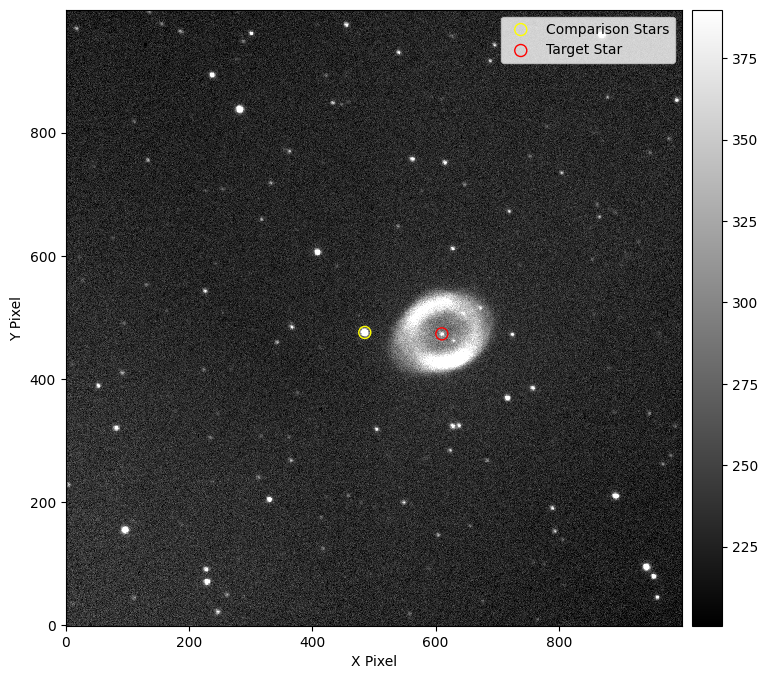

In [ ]:
# Extract matched stars' positions (xcenter, ycenter) from the table
comparison_x = matched_table[20]['xcenter']
comparison_y = matched_table[20]['ycenter']

target_x = 610.21314 # We can know this information from softwares like DS9
target_y = 473.28558

# Visualize the frame with matched stars highlighted
plt.figure(figsize=(10, 8))
interval = ZScaleInterval()
vmin, vmax = interval.get_limits(image_data)  # Scale for better visualization
plots.imshow(image_data, [0.5, 99.7], interpolation='nearest')
plt.scatter(comparison_x, comparison_y, s=75, facecolors='none', edgecolors='yellow', label='Comparison Stars')
plt.scatter(target_x, target_y, s=75, facecolors='none', edgecolors='red' , label='Target Star')
plt.xlabel('X Pixel')
plt.ylabel('Y Pixel')
plt.legend()
plt.grid(False)
plt.savefig('Target and Comparison stars' , format='png')
plt.show()

**Congratulations** on completing the Photometry Technique tutorial!

You have successfully learned how to process astronomical images, detect stars, perform aperture photometry, and calibrate magnitudes using data from multiple catalogs. These skills are essential for conducting accurate and reliable photometric analysis.

### Task: Explore Photometry with a Different Filter

To further enhance your understanding, try applying the techniques learned in this tutorial to images taken with a different filter. Follow these steps:

1. **Select a New Filter**: Choose a set of images captured with a different filter (e.g., B-band or R-band).

2. **Repeat the Analysis**: Perform the same steps of star detection, photometry, and calibration using the new filter data.

3. **Compare Results**: Analyze and compare the results obtained with the different filters. Consider how the filter choice affects the photometric measurements and calibration.

4. **Document Your Findings**: Write a brief report summarizing your findings, including any challenges encountered and insights gained from the comparison.

This task will help you understand the impact of filter selection on photometric analysis and improve your skills in handling diverse astronomical datasets. Good luck ^ ^